[*********************100%***********************]  1 of 1 completed


<Figure size 1400x600 with 0 Axes>

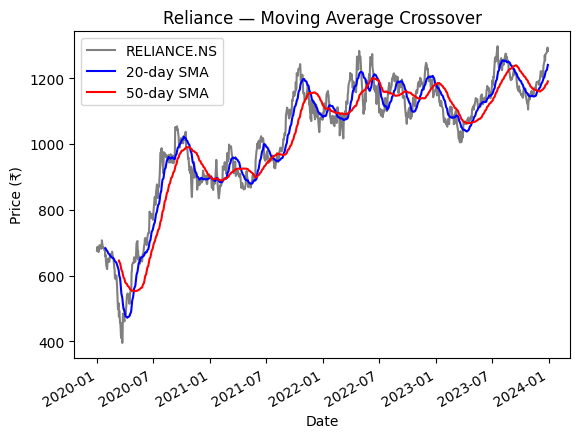

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download Reliance data
data = yf.download("RELIANCE.NS", start="2020-01-01", end="2024-01-01")
close = data['Close']

# Calculate moving averages
data['SMA_20'] = close.rolling(window=20).mean()
data['SMA_50'] = close.rolling(window=50).mean()

# Plot
plt.figure(figsize=(14, 6))
close.plot(label='Reliance Price', color='black', alpha=0.5)
data['SMA_20'].plot(label='20-day SMA', color='blue')
data['SMA_50'].plot(label='50-day SMA', color='red')
plt.title('Reliance — Moving Average Crossover')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.show()

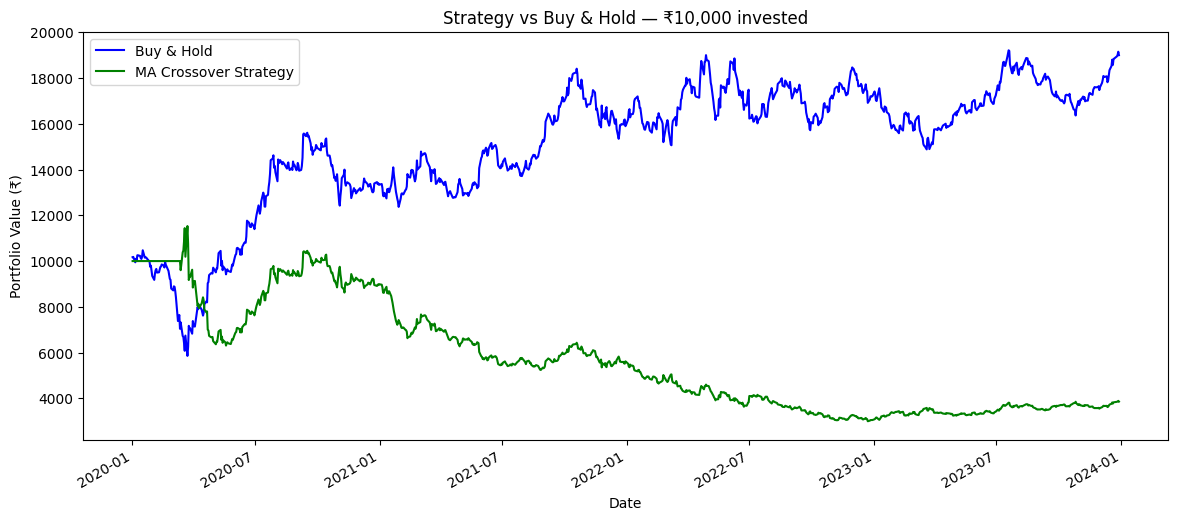

Buy & Hold final value: ₹18998
Strategy final value:   ₹3860


In [3]:
# Generate buy/sell signals
data['Signal'] = 0
data.loc[data['SMA_20'] > data['SMA_50'], 'Signal'] = 1  # Buy
data.loc[data['SMA_20'] < data['SMA_50'], 'Signal'] = -1  # Sell

# Calculate strategy returns
data['Daily_Return'] = close.pct_change()
data['Strategy_Return'] = data['Daily_Return'] * data['Signal'].shift(1)

# Cumulative returns
data['Buy_Hold'] = (1 + data['Daily_Return']).cumprod() * 10000
data['Strategy'] = (1 + data['Strategy_Return']).cumprod() * 10000

plt.figure(figsize=(14, 6))
data['Buy_Hold'].plot(label='Buy & Hold', color='blue')
data['Strategy'].plot(label='MA Crossover Strategy', color='green')
plt.title('Strategy vs Buy & Hold — ₹10,000 invested')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.show()

print(f"Buy & Hold final value: ₹{data['Buy_Hold'].iloc[-1]:.0f}")
print(f"Strategy final value:   ₹{data['Strategy'].iloc[-1]:.0f}")

In [4]:
# Analyze why the strategy failed
total_trades = (data['Signal'].diff() != 0).sum()
positive_days = (data['Strategy_Return'] > 0).sum()
negative_days = (data['Strategy_Return'] < 0).sum()

print(f"Total signal changes (trades): {total_trades}")
print(f"Profitable days: {positive_days}")
print(f"Losing days: {negative_days}")
print(f"Win rate: {positive_days/(positive_days+negative_days)*100:.1f}%")
print(f"\nAverage daily return (strategy): {data['Strategy_Return'].mean()*100:.4f}%")
print(f"Average daily return (buy&hold): {data['Daily_Return'].mean()*100:.4f}%")

Total signal changes (trades): 29
Profitable days: 452
Losing days: 490
Win rate: 48.0%

Average daily return (strategy): -0.0784%
Average daily return (buy&hold): 0.0840%


In [7]:
# Fix the close series first
close_clean = data['Close'].squeeze()

# Test different MA combinations
results = []

fast_windows = [10, 20, 30, 50]
slow_windows = [50, 100, 150, 200]

for fast in fast_windows:
    for slow in slow_windows:
        if fast >= slow:
            continue
            
        fast_ma = close_clean.rolling(window=fast).mean()
        slow_ma = close_clean.rolling(window=slow).mean()
        
        signal = np.where(fast_ma > slow_ma, 1, 
                 np.where(fast_ma < slow_ma, -1, 0))
        signal = pd.Series(signal, index=close_clean.index)
        
        daily_ret = close_clean.pct_change()
        strategy_ret = daily_ret * signal.shift(1)
        
        final_value = (1 + strategy_ret).cumprod().iloc[-1] * 10000
        sharpe = strategy_ret.mean() / strategy_ret.std() * np.sqrt(252)
        
        results.append({
            'Fast MA': fast,
            'Slow MA': slow,
            'Final Value (₹)': round(final_value, 0),
            'Sharpe Ratio': round(sharpe, 4)
        })

results_df = pd.DataFrame(results).sort_values('Sharpe Ratio', ascending=False)
print(results_df.to_string(index=False))

 Fast MA  Slow MA  Final Value (₹)  Sharpe Ratio
      50      200           8696.0       -0.0549
      10      100           7318.0       -0.2100
      10       50           6313.0       -0.2435
      20      200           7039.0       -0.3026
      30      200           6831.0       -0.3378
      20      100           6091.0       -0.4040
      30      100           5803.0       -0.4552
      10      200           6144.0       -0.4620
      50      100           5191.0       -0.5730
      20       50           3860.0       -0.6651
      50      150           4754.0       -0.7302
      10      150           4354.0       -0.8300
      20      150           4276.0       -0.8507
      30       50           2827.0       -0.9320
      30      150           2993.0       -1.2571


## What I learned — Day 5

**Moving Average Crossover Strategy:** A strategy that buys when the 
fast moving average crosses above the slow one, and sells when it 
crosses below.

**Backtest result:** All MA combinations failed on Reliance (2020-2024).
The best was 50-day fast + 200-day slow, but still turned ₹10,000 
into only ₹8,696 — a loss.

**Why it failed:** Reliance was in a strong uptrend. In a strong uptrend,
the best strategy is simply to hold. MA crossovers work better in 
sideways or choppy markets with clear reversals.

**Biggest lesson:** A strategy failing in backtesting is not a failure —
it's the whole point. You find out it doesn't work before risking 
real money. This is what quant research actually looks like.